En la siguiente celda se encuentran las funciones para hacer busqueda de vecino cercano y busqueda por radio con fuerza bruta.
Los datos al igual que con el arbol son generados con el modulo random en una lista de tuplas con coordenadas x,y.
La fuerza bruta fue implementada con listas, los datos se organizan con la coordenada x antes de usar las funciones para que el tiempo de ejecución no se vea afectado por el algoritmo de ordenamiento y muestre únicamente el teimpo del proceso de búsqueda

In [1]:
import random
from funciones_graficas import *
from KD_Tree import *
import math
datos = [(random.randint(0, 1000), random.randint(0, 1000)) for _ in range(10000)]
datos_ordenados = sorted(datos, key=lambda p: p[0])
##instancio el árbol##
arbol_prueba = KD_Tree(datos)
arbol_prueba.construir_arbol()

def distancia(p1, p2):
    """
    Calcula la distancia entre dos puntos.
    Args:
        p1 (tuple): punto 1 es una tupla con posiciones (x,y).
        p2 (tuple): punto 2 es una tupla con posiciones (x,y).

    Returns:
        float: devuelve la distancia euclidiana entre los dos puntos
    """
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

def buscar_vecino_cercano_fuerza_bruta(datos, objetivo):
    mejor_punto = datos[0]
    for punto in datos:
        if distancia(objetivo, punto)< distancia(mejor_punto, objetivo):
            mejor_punto = punto

def busqueda_radio_fuerza_bruta(datos, radio, objetivo):
    puntos_radio = []
    for punto in datos:
        if distancia(punto,objetivo)<radio:
            puntos_radio.append(punto)
    return puntos_radio

----------------------------------------------------------------------------------------------------------------------------------------------------


COMPARACION TIEMPOS DE EJECUCIÓN DE BUSQUEDAS EN ARBOL KD VS FUERZA BRUTA CON LISTAS

comparación búsqueda de vecinos cercanos

Para estas pruebas se procura utilizar los mismos argumentos en ambas funciones para conservar la igualdad de condiciones del experimento y no tener ruido que altere los resultados.
En lugar de usar solo un tiempo de ejecución se usa el tiempo promedio de 100 ejecuciones con el fin de suavizar los resultados que puedan generar condiciones atípicas (como que el arbol tenga que organizar la lista de datos y esta esté ordenada de forma descendente)

In [109]:
import time

suma_tiempos = 0
for i in range(100):
    inicio_KD = time.perf_counter()
    arbol_prueba.buscar_vecino_cercano((500,500))
    fin_KD = time.perf_counter()
    suma_tiempos += fin_KD-inicio_KD

print(f"Tiempo de ejecución promedio de búsqueda de vecino cercano con árbol KD: {suma_tiempos/100:.6f} segundos")

suma_tiempos = 0
for i in range(100):
    inicio_FB = time.perf_counter()
    buscar_vecino_cercano_fuerza_bruta(datos, (500,500))
    fin_FB = time.perf_counter()
    suma_tiempos += fin_FB-inicio_FB
    
print(f"Tiempo de ejecución promedio de búsqueda de vecino cercano con Fuerza Bruta: {suma_tiempos/100:.6f} segundos")




Tiempo de ejecución promedio de búsqueda de vecino cercano con árbol KD: 0.000032 segundos
Tiempo de ejecución promedio de búsqueda de vecino cercano con Fuerza Bruta: 0.003103 segundos


Tras probar con múltiples ejecuciones se puede notar un patrón en el aumento de tiempo que requiere mi algoritmo de busqueda por fuerza bruta:
cada vez que se aumenta la cantidad de datos en un factor de 10, la ejecucion requiere 10 veces más tiempo para encontrar a su vecino cercano.
Por otro lado, el algoritmo de busqueda de vecinos cercanos en el arbol KD se mantiene en las mismas cifras por más que aumente la cantidad de los datos.

Cuando la cantidad de datos es 10 los algoritmos tienen tiempos de ejecución parecidos y son del mismo orden (10^-5 segundos)
apartir de ahí cuando se aumenta en factor de 10 el algoritmo de fuerza bruta empieza a perder usabilidad.

----------------------------------------------------------------------------------------------------------------------------------------------------------


comparación busqueda por radio

In [110]:
suma_tiempos = 0
for i in range(100):
    inicio_KD = time.perf_counter()
    arbol_prueba.buscar_por_radio((500,500), 20)
    fin_KD = time.perf_counter()
    suma_tiempos += fin_KD-inicio_KD

print(f"Tiempo de ejecución promedio de búsqueda de vecino cercano con árbol KD: {suma_tiempos/100:.6f} segundos")

suma_tiempos = 0
for i in range(100):
    inicio_FB = time.perf_counter()
    busqueda_radio_fuerza_bruta(datos, 20, (500,500))
    fin_FB = time.perf_counter()
    suma_tiempos += fin_FB-inicio_FB
    
print(f"Tiempo de ejecución promedio de búsqueda de vecino cercano con Fuerza Bruta: {suma_tiempos/100:.6f} segundos")


Tiempo de ejecución promedio de búsqueda de vecino cercano con árbol KD: 0.000057 segundos
Tiempo de ejecución promedio de búsqueda de vecino cercano con Fuerza Bruta: 0.001912 segundos


Tras alrededor de 20 ejecuciones y aumento en la cantidad de datos llegué a la siguiente conclusión:
cuando el radio de búsqueda es muy grande se tienen que recorrer muchas ramas y la velocidad de ejecución disminuye. Cuando se disminuye el radio de forma en que abarca una región pequeña de los datos la búsqueda es capaz de descartar muchas ramas del árbol disminuyendo así el tiempo que tarda el algoritmo.
Como el algoritmo de fuerza bruta siempre tiene que buscar en todos los datos su tiempo no disminuye si se decrementa el radio.
En resumen: El algoritmo de fuerza bruta se queda corto cuando la cardinalidad de los datos es muy grande y sus tiempos son independientes del radio de búsqueda.
La búsqueda con un árbol KD funciona excelente cuando el radio no abarca gran parte de la región de los datos, de lo contrario funciona de una forma parecida a fuerza bruta porque el algoritmo tiene que buscar en la gran mayoría de las ramas.

--------------------------------------------------------------------------------------------------------------------------------------------------------------

En las siguientes celdas se comparan los tiempos de ejecucion de ambos algoritmos ejecutados por fuerza bruta y por arboles kd, ambos con diferentes cantidades de datos para poder apreciar cómo se comportan

In [11]:
import time
import random

def medir_rendimiento(tamanos_n, objetivo=(50, 50), radio=5.0):
    """
    Ejecuta las pruebas y retorna un diccionario con los resultados.
    """
    resultados = {
        'n': tamanos_n,
        'nn_fb': [],
        'nn_kd': [],
        'radio_fb': [],
        'radio_kd': []
    }

    for n in tamanos_n:
        # Generar datos de prueba
        datos = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(n)]
        
        # Construir el árbol (esto es pre-procesamiento)
        arbol = KD_Tree(datos)
        arbol.construir_arbol()

        # --- Medición Vecino Cercano ---
        # Fuerza Bruta
        t0 = time.time()
        buscar_vecino_cercano_fuerza_bruta(datos, objetivo)
        resultados['nn_fb'].append(time.time() - t0)
        
        # KD-Tree
        t0 = time.time()
        arbol.buscar_vecino_cercano(objetivo)
        resultados['nn_kd'].append(time.time() - t0)

        # --- Medición Búsqueda por Radio ---
        # Fuerza Bruta
        t0 = time.time()
        busqueda_radio_fuerza_bruta(datos, radio, objetivo)
        resultados['radio_fb'].append(time.time() - t0)
        
        # KD-Tree
        t0 = time.time()
        arbol.buscar_por_radio(objetivo, radio)
        resultados['radio_kd'].append(time.time() - t0)
        
        print(f"Finalizada prueba para N={n}")

    return resultados

Finalizada prueba para N=100
Finalizada prueba para N=1000
Finalizada prueba para N=5000
Finalizada prueba para N=10000
Finalizada prueba para N=20000


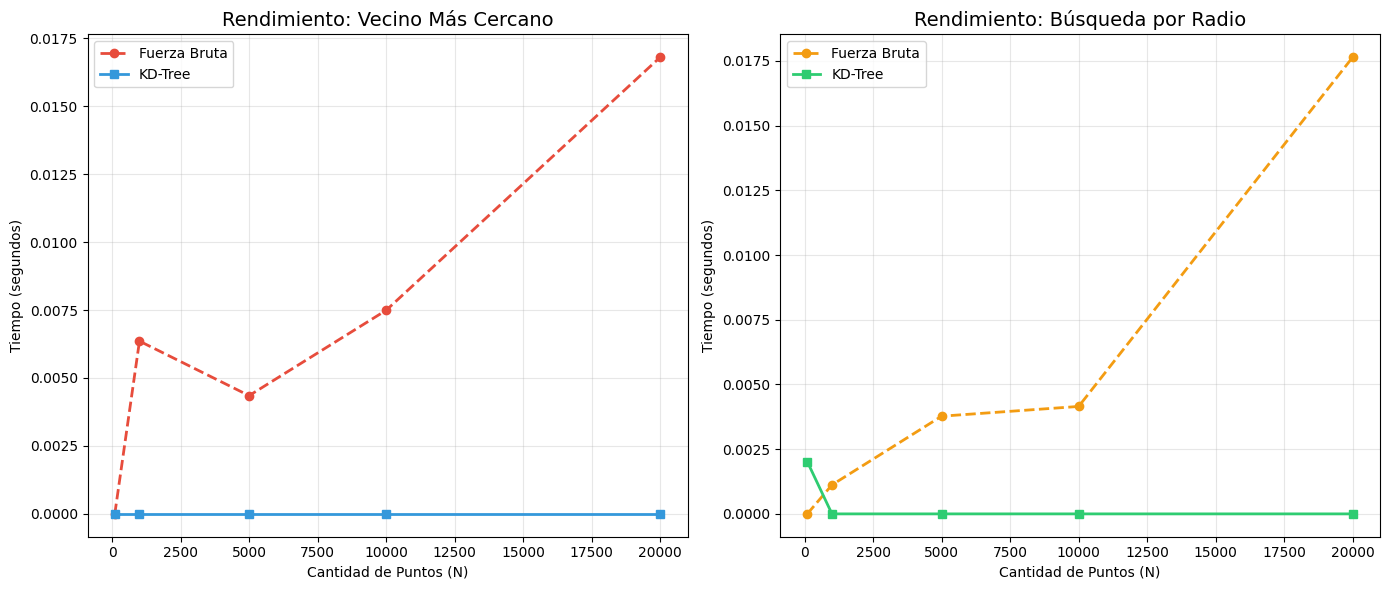

In [16]:
# Definimos los tamaños que queremos probar
tamanos = [100, 1000, 5000, 10000, 20000]

# Fase 1: Medir (esto puede tardar)
datos_rendimiento = medir_rendimiento(tamanos)

# Fase 2: Graficar (esto es instantáneo)
graficar_comparativa(datos_rendimiento)

las lineas de los algoritmos kd se ven como si estuviran aplastadas contra el eje x, esto sucede porque sus tiempos te ejecución son logarítmicos y los de fuerza bruta son lineales. para este laboratorio no alcancé a ajustar la escala de los datos para visualizar correctamente sus comportamientos.
En general, a partir de los 10.000 datos el tiempo de ejecucion de la fuerza bruta sube un orden de magnitud respecto al tiempo de los arboles KD. Podemos decir que los algoritmos KD empiezan a ser mucho mejores a partir de 10.000 datos